In [ ]:
!pip install -q librosa soundfile seaborn scikit-learn

In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub
import librosa

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import requests
import json

url = f"https://api.figshare.com/v2/articles/19291472"
response = requests.get(url)

if response.status_code != 200:
    raise Exception(f"Failed to access Figshare API: {response.status_code}")

article = response.json()

print("Dataset title:")
print(article["title"])

print("\nFiles:")
for f in article["files"]:
    print(f["name"], "->", round(f["size"] / (1024**2), 2), "MB")

Dataset title:
Large-Scale Audio Dataset for Emergency Vehicle Sirens and Road Noises

Files:
Ambulance_final.csv -> 0.43 MB
Road_final.csv -> 0.44 MB
Emergency Vehicle Sirens.zip -> 1035.92 MB
Road Noises.zip -> 1152.24 MB


In [ ]:
import os
import requests
import zipfile
from tqdm.auto import tqdm

download_dir = "/content/siren_dataset"
os.makedirs(download_dir, exist_ok=True)

files_info = article["files"]

for file_info in files_info:
    file_name = file_info["name"]

    if not file_name.lower().endswith('.zip'):
        continue

    download_url = file_info["download_url"]
    output_path = os.path.join(download_dir, file_name)
    print(f"Downloading: {file_name}")

    response = requests.get(download_url, stream=True)
    total_size = int(response.headers.get("content-length", 0))

    with open(output_path, "wb") as f:
        with tqdm(total=total_size, unit="B", unit_scale=True, desc=file_name) as pbar:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    print("Saved:", output_path)

    print(f"Extracting {file_name}...")
    try:
        with zipfile.ZipFile(output_path, 'r') as zip_ref:
            zip_ref.extractall(download_dir)
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print(f"Error: {file_name} is corrupted or not a valid zip file.")

    print()

Downloading: Emergency Vehicle Sirens.zip


Emergency Vehicle Sirens.zip:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

Saved: /content/siren_dataset/Emergency Vehicle Sirens.zip
Extracting Emergency Vehicle Sirens.zip...
Extraction complete.

Downloading: Road Noises.zip


Road Noises.zip:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Saved: /content/siren_dataset/Road Noises.zip
Extracting Road Noises.zip...
Extraction complete.



In [ ]:
for root, dirs, files in os.walk(download_dir):
    level = root.replace(download_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

siren_dataset/
    Emergency Vehicle Sirens.zip
    Road Noises.zip
    Ambulance data/
        ambulance356.wav
        ambulance4.wav
        ambulance904.wav
        ambulance390.wav
        ambulance896.wav
        ambulance365.wav
        ambulance285.wav
        ambulance430.wav
        ambulance431.wav
        ambulance758.wav
    Road Noises/
        road14.wav
        road610.wav
        road658.wav
        road126.wav
        road461.wav
        road746.wav
        road186.wav
        road823.wav
        road651.wav
        road551.wav


In [ ]:
wav_files = glob.glob(f"{download_dir}/**/*.wav", recursive=True)

data = []

for file_path in wav_files:
    path_lower = file_path.lower()
    if "ambulance data" in path_lower:
        label = 1
        class_name = "Siren"
    elif "road noises" in path_lower:
        label = 0
        class_name = "No Siren"
    else:
        continue

    data.append({
        "filepath": file_path,
        "label": label,
        "class_name": class_name
    })

df = pd.DataFrame(data)

print("Total labeled files:", len(df))
print("\nClass distribution:")
print(df["class_name"].value_counts())

Total labeled files: 1834

Class distribution:
class_name
Siren       932
No Siren    902
Name: count, dtype: int64


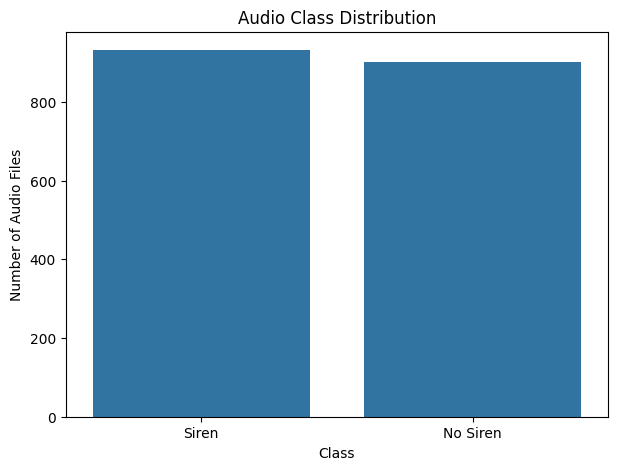

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="class_name")
plt.title("Audio Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Audio Files")
plt.show()

In [ ]:
from IPython.display import Audio, display

sample_siren = df[df["label"] == 1].sample(1, random_state=42).iloc[0]["filepath"]
sample_noise = df[df["label"] == 0].sample(1, random_state=42).iloc[0]["filepath"]

print("SIREN SAMPLE:")
display(Audio(sample_siren))

print("\nROAD NOISE SAMPLE:")
display(Audio(sample_noise))

SIREN SAMPLE:



ROAD NOISE SAMPLE:


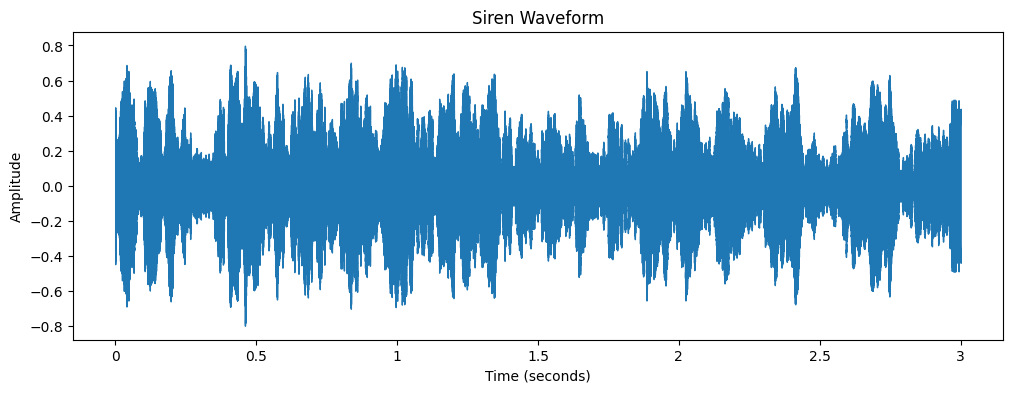

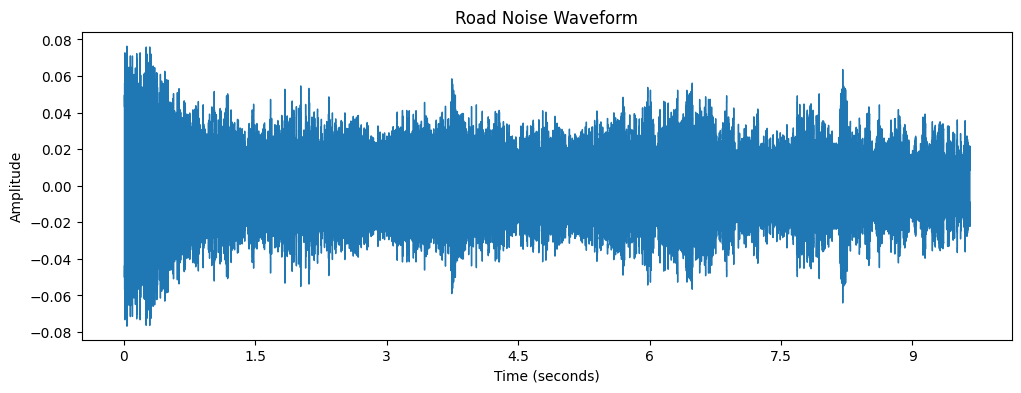

In [ ]:
def plot_waveform(file_path, title):
    y, sr = librosa.load(file_path, sr=16000)
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.show()

plot_waveform(sample_siren, "Siren Waveform")
plot_waveform(sample_noise, "Road Noise Waveform")

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"])

print("Train:", len(train_df))
print(train_df["class_name"].value_counts())

print("\nValidation:", len(val_df))
print(val_df["class_name"].value_counts())

print("\nTest:", len(test_df))
print(test_df["class_name"].value_counts())

Train: 1283
class_name
Siren       652
No Siren    631
Name: count, dtype: int64

Validation: 275
class_name
Siren       140
No Siren    135
Name: count, dtype: int64

Test: 276
class_name
Siren       140
No Siren    136
Name: count, dtype: int64


In [ ]:
yamnet_model_handle = "https://tfhub.dev/google/yamnet/1"
yamnet_model = hub.load(yamnet_model_handle)

print("YAMNet loaded successfully!")

YAMNet loaded successfully!


In [ ]:
def load_wav_16k_mono(filename):
    audio, sr = librosa.load(filename, sr=16000, mono=True)
    audio = audio.astype(np.float32)

    return audio

# -------------------- test on one sample ----------------
sample_file = train_df.iloc[0]["filepath"]
audio = load_wav_16k_mono(sample_file)

print("File:", sample_file)
print("Audio shape:", audio.shape)
print("Duration:", len(audio) / 16000, "seconds")

File: /content/siren_dataset/Ambulance data/ambulance110.wav
Audio shape: (196267,)
Duration: 12.2666875 seconds


In [ ]:
def extract_yamnet_embeddings(file_path, label):
    audio = load_wav_16k_mono(file_path)

    scores, embeddings, spectrogram = yamnet_model(audio)
    embeddings = embeddings.numpy()

    labels = np.full(len(embeddings), label, dtype=np.int32)

    return embeddings, labels

# -------------------- test on one sample ----------------
embeddings, labels = extract_yamnet_embeddings(sample_file, train_df.iloc[0]["label"])

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embeddings shape: (25, 1024)
Labels shape: (25,)


In [ ]:
def build_embeddings_dataframe(dataframe, Name):
    print(f"------------------------[{Name}]----------------------------")
    all_embeddings = []
    all_labels = []

    for i, row in enumerate(dataframe.itertuples(index=False)):

        embeddings, labels = extract_yamnet_embeddings(row.filepath, row.label)

        all_embeddings.append(embeddings)
        all_labels.append(labels)

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(dataframe)} files")

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_embeddings, all_labels

In [ ]:
X_train, y_train = build_embeddings_dataframe(train_df, "Train")
print("\nTrain embeddings:", X_train.shape)
print("Train labels:", y_train.shape)

X_val, y_val = build_embeddings_dataframe(val_df, "Validation")
print("\nValidation embeddings:", X_val.shape)

X_test, y_test = build_embeddings_dataframe(test_df, "Test")
print("\nTest embeddings:", X_test.shape)

------------------------[Train]----------------------------
Processed 100/1283 files
Processed 200/1283 files
Processed 300/1283 files
Processed 400/1283 files
Processed 500/1283 files
Processed 600/1283 files
Processed 700/1283 files
Processed 800/1283 files
Processed 900/1283 files
Processed 1000/1283 files
Processed 1100/1283 files
Processed 1200/1283 files

Train embeddings: (20585, 1024)
Train labels: (20585,)
------------------------[Validation]----------------------------
Processed 100/275 files
Processed 200/275 files

Validation embeddings: (4297, 1024)
------------------------[Test]----------------------------
Processed 100/276 files
Processed 200/276 files

Test embeddings: (4298, 1024)


In [ ]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

classifier.summary()

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 590,593 (2.25 MB)

 Trainable params: 590,593 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = classifier.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9598 - loss: 0.2011 - val_accuracy: 0.9709 - val_loss: 5.8519 - learning_rate: 0.0100
Epoch 2/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9674 - loss: 0.3648 - val_accuracy: 0.9718 - val_loss: 0.7609 - learning_rate: 0.0100
Epoch 3/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9679 - loss: 0.1652 - val_accuracy: 0.9784 - val_loss: 4.1675 - learning_rate: 0.0100
Epoch 4/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9652 - loss: 0.2342 - val_accuracy: 0.9732 - val_loss: 1.9319 - learning_rate: 0.0100
Epoch 5/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9689 - loss: 0.3058 - val_accuracy: 0.9702 - val_loss: 0.1447 - learning_rate: 0.0100
Epoch 6/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9685 - loss: 0.1179 - val_accuracy: 0.9697 - val_loss: 1.0668 - learning_rate: 0.0100
Epoch 7/40
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9708 - loss: 0.1094 - 

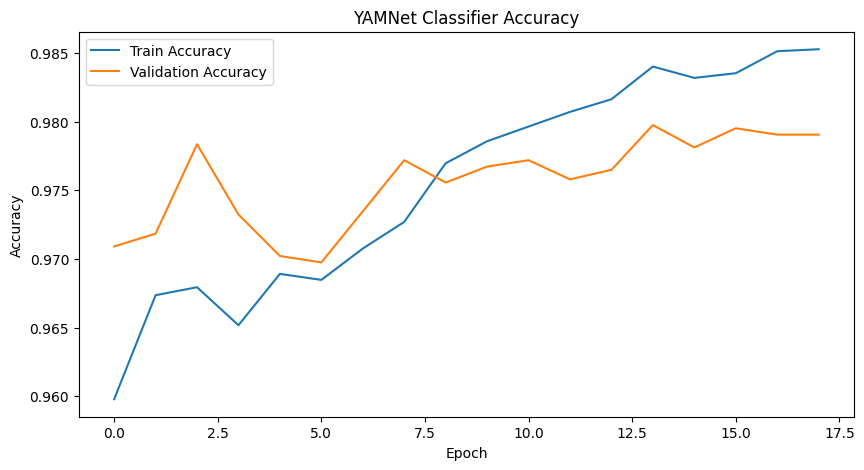

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("YAMNet Classifier Accuracy")
plt.legend()
plt.show()

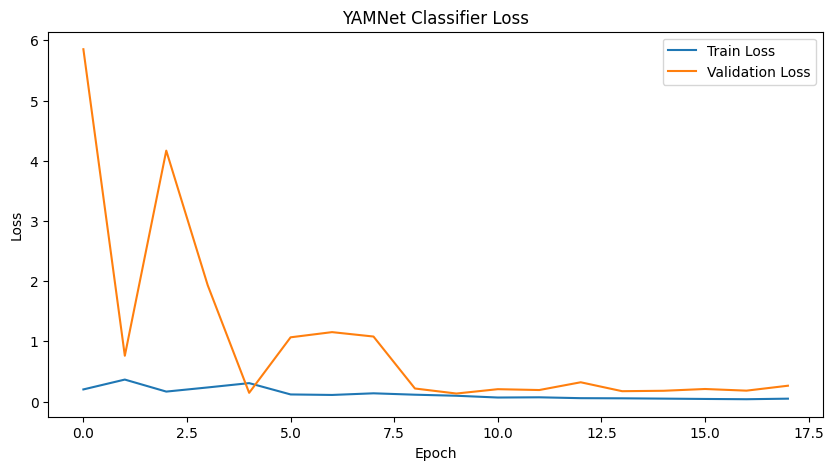

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YAMNet Classifier Loss")
plt.legend()
plt.show()

In [ ]:
y_prob = classifier.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
def predict_audio_file(file_path, threshold=0.5):
    audio = load_wav_16k_mono(file_path)
    scores, embeddings, spectrogram = yamnet_model(audio)
    embeddings = embeddings.numpy()

    frame_probabilities = classifier.predict(embeddings, verbose=0).flatten()
    probability = float(np.mean(frame_probabilities))

    prediction = 1 if probability >= threshold else 0
    label = "Siren" if prediction == 1 else "No Siren"
    confidence = probability if prediction == 1 else 1 - probability

    return {
        "label": label,
        "probability": probability,
        "confidence": confidence,
        "frame_probabilities": frame_probabilities
    }

In [ ]:
siren_file = test_df[test_df["label"] == 1].iloc[0]["filepath"]
result = predict_audio_file(siren_file)

print("File:", siren_file)
print("\nPrediction:", result["label"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")

# ----------------------------------------
print("-"*50)

noise_file = test_df[test_df["label"] == 0].iloc[0]["filepath"]
result = predict_audio_file(noise_file)

print("File:", noise_file)
print("\nPrediction:", result["label"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")

File: /content/siren_dataset/Ambulance data/ambulance419.wav

Prediction: Siren
Confidence: 70.92%
--------------------------------------------------
File: /content/siren_dataset/Road Noises/road168.wav

Prediction: No Siren
Confidence: 84.89%


In [ ]:
def evaluate_files(dataframe):
    y_true = []
    y_prob = []

    for i, row in enumerate(dataframe.itertuples(index=False)):
        result = predict_audio_file(row.filepath)
        y_true.append(row.label)
        y_prob.append(result["probability"])

        if (i + 1) % 25 == 0:
            print(f"Evaluated {i + 1}/{len(dataframe)} files")

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    return y_true, y_prob, y_pred

In [ ]:
y_true, y_prob, y_pred = evaluate_files(test_df)

Evaluated 25/276 files
Evaluated 50/276 files
Evaluated 75/276 files
Evaluated 100/276 files
Evaluated 125/276 files
Evaluated 150/276 files
Evaluated 175/276 files
Evaluated 200/276 files
Evaluated 225/276 files
Evaluated 250/276 files
Evaluated 275/276 files


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Test Results")
print("============")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Test Results
Accuracy : 0.9420
Precision: 0.9026
Recall   : 0.9929
F1 Score : 0.9456


In [ ]:
cr = classification_report(y_true, y_pred, target_names=["No Siren", "Siren"])

print(cr)

              precision    recall  f1-score   support

    No Siren       0.99      0.89      0.94       136
       Siren       0.90      0.99      0.95       140

    accuracy                           0.94       276
   macro avg       0.95      0.94      0.94       276
weighted avg       0.95      0.94      0.94       276



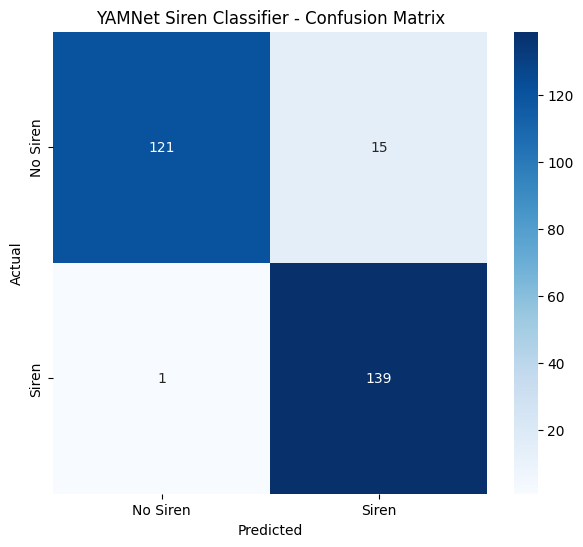

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Siren", "Siren"],
    yticklabels=["No Siren", "Siren"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("YAMNet Siren Classifier - Confusion Matrix")
plt.show()

In [ ]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
results = []

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)
    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.938406,0.896774,0.992857,0.942373
1,0.4,0.938406,0.896774,0.992857,0.942373
2,0.5,0.942029,0.902597,0.992857,0.945578
3,0.6,0.945652,0.913907,0.985714,0.948454
4,0.7,0.942029,0.930556,0.957143,0.943662


In [ ]:
classifier_path = "/content/siren_classifier.keras"

classifier.save(classifier_path)

print("Classifier saved successfully:")
print(classifier_path)

Classifier saved successfully:
/content/siren_classifier.keras


In [ ]:
loaded_classifier = tf.keras.models.load_model("/content/siren_classifier.keras")

print("Classifier loaded successfully!")

Classifier loaded successfully!


In [ ]:
best_threshold = 0.5
config = {
    "sample_rate": 16000,
    "threshold": best_threshold,
    "classes": {
        "0": "No Siren",
        "1": "Siren"
    }
}

with open("/content/siren_model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Config saved!")

Config saved!


In [ ]:
from google.colab import files

files.download("/content/siren_classifier.keras")
files.download("/content/siren_model_config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>